In [2]:
import torch
from ase.io import read, write, Trajectory
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
from curator.utils import create_model_from_mace

In [3]:
feats = torch.load('feats.pth')

/tmp/ipykernel_301343/1772802861.py:1: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  feats = torch.load('feats.pth')


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

/home/xinyang/miniconda3/lib/python3.13/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(


/home/yangxin/miniconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


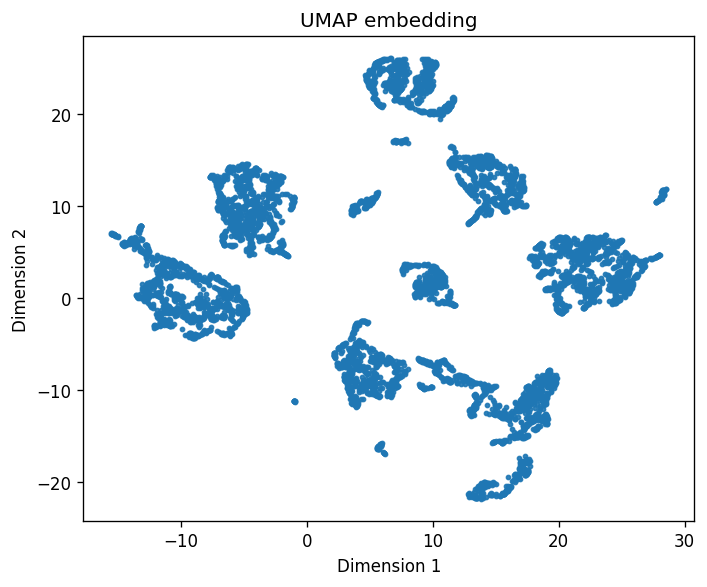

In [5]:
X = feats.squeeze().numpy()
do_pca = (X.shape[1] > 100)
if do_pca:
    X_in = PCA(n_components=50, random_state=42).fit_transform(X)
else:
    X_in = X

reducer = umap.UMAP(
    n_neighbors=25,          # 中等邻域；保留簇，又不至于太碎
    min_dist=0.25,           # 稍大→簇不至于过于拥挤，分布更均匀
    spread=1.2,              # 略放大整体尺度，避免重叠
    repulsion_strength=1.5,  # ↑ 更强的排斥，让全局更均匀
    negative_sample_rate=10, # ↑ 提升“推开”采样频率，布局更均匀
    set_op_mix_ratio=0.5,    # 局部/全局折中
    init='spectral',         # 全局布局更稳定
    metric='euclidean',      # 嵌入向量可用 'cosine'
    random_state=45
)
emb2d = reducer.fit_transform(X_in)   # (n, 2)

# ===== 4) 作图 =====
plt.figure(figsize=(6, 5), dpi=120)
plt.scatter(emb2d[:, 0], emb2d[:, 1], s=6, alpha=0.9)
plt.title("UMAP embedding")
plt.xlabel("Dimension 1") 
plt.ylabel("Dimension 2")
plt.tight_layout()
plt.show()

Note: you may need to restart the kernel to use updated packages.


/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 20987 (\N{CJK UNIFIED IDEOGRAPH-51FB}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:342: UserWarning: Glyph 26463 (\N{CJK UNIFIED IDEOGRAPH-675F}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/yangxin/miniconda3/lib/python3.12/site-packages/ipympl/backend_nbagg.py:34

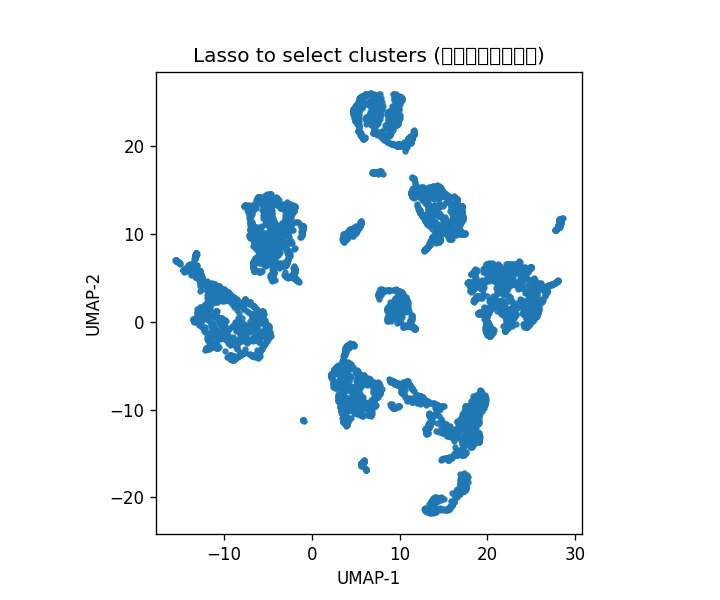

In [15]:
# ==== 依赖与交互后端（JupyterLab 推荐 widget；经典 Notebook 可用 notebook）====
%pip -q install ipympl mplcursors ipywidgets
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path
import mplcursors
from ipywidgets import VBox, HBox, Button, IntText, HTML

# ====== 你的数据 ======
# 你的 UMAP 结果：emb2d 形状 (n, 2)
# 如果你已经有 emb2d / orig_idx，就注释掉这段示例数据
try:
    emb2d
except NameError:
    n = 1500
    rng = np.random.default_rng(42)
    emb2d = np.vstack([
        rng.normal([0,0], 0.4, size=(300,2)),
        rng.normal([5,6], 0.6, size=(500,2)),
        rng.normal([-6,8], 0.5, size=(400,2)),
        rng.normal([8,-5], 0.7, size=(300,2)),
    ])
# 原始数据的行号（如果你的数据经过筛选/洗牌，传入对应的映射）
orig_idx = np.arange(len(emb2d))

# ====== 交互式绘图 ======
fig, ax = plt.subplots(figsize=(6,5), dpi=120)
pts = ax.scatter(emb2d[:,0], emb2d[:,1], s=8, alpha=0.9)
ax.set_aspect('equal', 'box')
ax.set_title("Lasso to select clusters (双击结束一次圈选)")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

# 悬浮显示单点 index（emb2d 行号；原始行号用 orig_idx[i]）
cursor = mplcursors.cursor(pts, hover=True)
@cursor.connect("add")
def _show(sel):
    i = sel.index
    sel.annotation.set_text(f"idx={i}, orig={orig_idx[i]}")

# ====== 圈选收集 ======
selected_batches = []  # 每次圈选的 emb2d 行号数组
last_inds = np.array([], dtype=int)

def onselect(verts):
    global last_inds
    path = Path(verts)
    inds = np.nonzero(path.contains_points(emb2d))[0]
    last_inds = inds
    selected_batches.append(inds)
    # 高亮最新一次圈选（把这些点画大一点/更深色）
    sizes = np.full(len(emb2d), 8, dtype=float)
    sizes[inds] = 30
    pts.set_sizes(sizes)
    info_html.value = f"<b>本次圈选</b> {len(inds)} 点；累计批次数：{len(selected_batches)}"

lasso = LassoSelector(ax, onselect)

# ====== 保存控件 ======
info_html = HTML(value="等待圈选…")
btn_save_last = Button(description="保存本次圈选", button_style='info')
btn_save_all  = Button(description="保存全部圈选", button_style='success')
name_last     = IntText(value=0, description="批次号", tooltip="保存哪一批（0 起）")

def save_indices(arr, prefix):
    np.save(f"{prefix}.npy", arr)
    # 简单写 CSV
    np.savetxt(f"{prefix}.csv", arr.reshape(-1,1), fmt="%d", delimiter=",")
    return f"已保存为 {prefix}.npy / {prefix}.csv"

def on_save_last(_):
    # 优先用 name_last 指定的批次；否则用 last_inds
    k = name_last.value
    if 0 <= k < len(selected_batches):
        inds = selected_batches[k]
    else:
        inds = last_inds
    msg = save_indices(orig_idx[inds], prefix="umap_selected_last")
    info_html.value = f"<b>{msg}</b>（条数：{len(inds)}）"

def on_save_all(_):
    # 合并所有圈选并去重
    if not selected_batches:
        info_html.value = "还没有圈选结果。"
        return
    merged = np.unique(np.concatenate(selected_batches))
    msg = save_indices(orig_idx[merged], prefix="umap_selected_merged")
    info_html.value = f"<b>{msg}</b>（合并去重后条数：{len(merged)}）"

btn_save_last.on_click(on_save_last)
btn_save_all.on_click(on_save_all)

display(VBox([
    info_html,
    HBox([btn_save_last, name_last, btn_save_all]),
    fig.canvas  # 把图也放在控件下面，方便交互
]))


In [3]:
traj = Trajectory('mace-data/all_nointer_0611_forcedel_virial.traj')

In [4]:
from ase.visualize import view

In [5]:
view(traj[5215])

<Popen: returncode: None args: ['/home/xinyang/miniconda3/bin/python', '-m',...>

In [6]:
len(traj[5215])

330

In [19]:
num_atoms = []
for atoms in traj:
    num_atoms.append(len(atoms))

num_atoms = set(num_atoms)

In [36]:
for i, atoms in enumerate(traj):
    if len(atoms) == 648:
        print(i)
        break

53295


In [8]:
from ase.data.colors import jmol_colors
from ase.io.pov import get_bondpairs
from ase.io import read, write, Trajectory
import subprocess
import os
import numpy as np
from ase.data import covalent_radii

In [57]:
#rotation = '-90x,-90y,0z'
# rotation = '45x,45y,45z'
rotation = '0x,0y,0z'
# (x1, y1, x2, y2), x1, y1 is the position of left-bottom corner, x2, y2 is the position of right-up corner
bbox = (-10, -20, 20, 5)
bbox = (-10, -3, 20, 20)
bbox = (-10, -10, 50, 50)
generic_settings = {
    'rotation'       : rotation, # text string with rotation (default='' )
    'bbox'           : bbox,
    'radii'          : .95, # float, or a list with one float per atom
    'show_unit_cell' : 0,   # 0, 1, or 2 to not show, show, and show all of cell
#    'colors'         : colors,
#    'scale'          : scale,
#    'extra_offset'   : (0., 0.)
}


povray_settings = {
#    'run_povray'     : False, # Run povray or just write .pov + .ini files
    'display'        : False,# Display while rendering
    'pause'          : True, # Pause when done rendering (only if display)
    'transparent'    : True,# Transparent background
    'canvas_width'   : 2000, # Width of canvas in pixels
    'canvas_height'  : None, # Height of canvas in pixels
    'camera_dist'    : 50.,  # Distance from camera to front atom
    'image_plane'    : None, # Distance from front atom to image plane
    'camera_type'    : 'orthographic', #'orthographic', #'perspective', # perspective, ultra_wide_angle
    'point_lights'   : [],             # [[loc1, color1], [loc2, color2],...]
    'area_light'     : [(2., 3., 40.), # location
                        'White',       # color
                        .7, .7, 3, 3], # width, height, Nlamps_x, Nlamps_y
    'background'     : 'White',        # color
    'celllinewidth'  : 0.02,  # Radius of the cylinders representing the cell
    'textures'       : None, 
    'transmittances' : None,
    'bondlinewidth'  : 0.1,
    'bondatoms'      : [],
}

def plot_atoms(plt_atoms, name, render=True, remove_pov=True):
    atoms = plt_atoms.copy()
    atoms.translate((0, 0, 0))
    atoms.wrap()
    
    # control radii
    Z = atoms.get_atomic_numbers()
    colors = jmol_colors[Z]
    radii = covalent_radii[atoms.numbers] * 0.8
    mask = atoms.numbers != 3
    radii[mask] *= 0.5
    # transmit = np.zeros_like(atoms.get_atomic_numbers(), dtype=float)
    transmit = np.where(atoms.numbers != 3, 0.8, 0.0)
    textures = ['jmol'] * len(atoms)

    ase_settings = generic_settings.copy()
    pov_settings = povray_settings.copy()

    ase_settings['colors'] = colors
    ase_settings['radii'] = radii
    pov_settings['bondatoms'] = get_bondpairs(atoms)
    pov_settings['transmittances'] = transmit
    pov_settings['textures'] = textures
    write('{}.pov'.format(name), atoms, povray_settings=pov_settings, **ase_settings)
    if render:
        pov_run = subprocess.run('povray {}.ini'.format(name), 
                                 shell=True, 
                                 stdout=subprocess.DEVNULL, 
                                 stderr=subprocess.DEVNULL)
    if remove_pov:
        os.remove('{}.ini'.format(name))
        os.remove('{}.pov'.format(name))

In [44]:
atoms.numbers

array([8, 6, 8, ..., 9, 9, 9])

In [45]:
import numpy as np

In [59]:
plot_atoms(atoms, 'test')

In [49]:
np.where(atoms.numbers != 3, 0.8, 0.0)

array([0.8, 0.8, 0.8, ..., 0.8, 0.8, 0.8])

In [47]:
atoms.numbers != 3

array([ True,  True,  True, ...,  True,  True,  True])

In [56]:
plot_atoms(atoms, 'large')

In [28]:
from ase.symbols import atomic_numbers
Z = {
    1: atomic_numbers['C'],
    2: atomic_numbers['F'],
    3: atomic_numbers['H'],
    4: atomic_numbers['Li'],
    5: atomic_numbers['O'],
    6: atomic_numbers['P'],
}

In [40]:
atoms = read('data/ec_dec_37_big.data', format='lammps-data', Z_of_type=Z)

In [1]:
import torch
from ase.io import read, write, Trajectory
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"
from curator.utils import create_model_from_mace

m_sch_128 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_128_0709_cue_123_stagetwo.model')
m_sch_64 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_64_0703_cue_123_stagetwo.model')

m_ft_mp_pt_head = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model')
m_ft_mp = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456_default_head_only.model')

m_ft_off_pt_head = torch.load('mace-model/finetuned_MACE_off23_electrolytes_large_multihead_EA_0702_s123_default_head_only.model')
m_ft_off = torch.load('mace-model/finetuned_MACE_off23_electrolytes_large_multihead_EA_0702_s123.model')

m_dt_mp = torch.load('mace-model/mace_distill_DT_lr1.725e-3_E1k_F1k_l_max5_0717_cuequ_epoch20_best.model')
m_dt_off = torch.load('mace-model/mace_distill_DT_lr1.725e-3_E1k_F1k_l_max5_0718_cuequ_off_epoch20_best.model')

/home/xinyang/miniconda3/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
Failed to get GPU information from pynvml: Not Supported. Using default values.


GPU information: NVIDIA RTX A6000, 8, 6, 45, 84, 300, 2100


/tmp/ipykernel_109818/2377628614.py:7: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  m_sch_128 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_128_0709_cue_123_stagetwo.model')
/tmp/ipykernel_109818/2377628614.py:8: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  m_sch_64 = torch.load('mace-model/mace_scratch_electrolytes_l2_el3_64_0703_cue_123_stagetwo.model')
/tmp/ipykernel_109818/2377628614.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  m_ft_mp_pt_head = torch.load('mace-model/finetuned_MACE_mp_electrolytes_medium_multihead_EA_0626_FP64_s456.model')
/tmp/ipykernel_1

In [2]:
sch_128 = create_model_from_mace(m_sch_128)
sch_64 = create_model_from_mace(m_sch_64)

ft_mp_pt_head = create_model_from_mace(m_ft_mp_pt_head)
ft_mp = create_model_from_mace(m_ft_mp)

ft_off_pt_head = create_model_from_mace(m_ft_off_pt_head)
ft_off = create_model_from_mace(m_ft_off)

dt_mp = create_model_from_mace(m_dt_mp)
dt_off = create_model_from_mace(m_dt_off)

/home/xinyang/miniconda3/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/xinyang/miniconda3/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/xinyang/miniconda3/lib/python3.13/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/xinyang/miniconda3/

In [3]:
images = Trajectory('mace-data/all_nointer_0611_forcedel_virial.traj')

In [16]:
atoms = images[-1]

In [6]:
# get features
from curator.select import FeatureExtractor, FeatureStatistics
from curator.data import AseDataset
dataset = AseDataset(images, cutoff=5.0)
extractor = FeatureExtractor(dt_mp)
feat_stats = FeatureStatistics([dt_mp], dataset)

In [8]:
feats = feat_stats.get_features()

/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


: 

In [13]:
from curator.layer.utils import find_layer_by_name_recursive

In [14]:
layer = find_layer_by_name_recursive(dt_mp, 'readouts[-1]')

In [27]:
mace_model = dt_mp

In [32]:
create_model_from_mace(dt_mp)

/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/yangxin/miniconda3/

NeuralNetworkPotential(
  (representation): MACE(
    (embeddings): ModuleDict(
      (onehot_embedding): OneHotAtomEncoding(
        (type_mapper): TypeMapper(symbol_to_type={'H': 0, 'Li': 1, 'C': 2, 'O': 3, 'F': 4, 'P': 5}
      )
      (radial_basis): RadialBasisEdgeEncoding(
        (basis): BesselBasis(cutoff=5.0, num_basis=8, prefactor=0.6324555320336759, trainable=False)
        (cutoff_fn): PolynomialCutoff(cutoff=5.0, power=5.0)
      )
      (sphere_harmonics): SphericalHarmonicEdgeAttrs(
        (sh): SphericalHarmonics()
      )
      (chemical_embedding): AtomwiseLinear(
        (linear): Linear(6x0e -> 64x0e | 384 weights)
      )
    )
    (interactions): ModuleList(
      (0): RealAgnosticInteractionBlock(
        (linear_up): Linear(64x0e -> 64x0e | 4096 weights)
        (conv_tp): TensorProduct(64x0e x 1x0e+1x1o+1x2e+1x3o -> 64x0e+64x1o+64x2e+64x3o | 256 paths | 256 weights)
        (conv_tp_weights): FullyConnectedNet[8, 64, 64, 64, 256]
        (linear): Linear(64x0

In [12]:
features = feat_stats.get_features()

KeyError: 'node_attrs'

In [15]:
layers.children()

<generator object Module.children at 0x76c39c187b90>